In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch, numpy as np, pandas as pd, json
from pathlib import Path

DATA = Path('/content/drive/MyDrive/landslide')
OUT  = DATA / 'outputs'
(OUT / 'models').mkdir(parents=True, exist_ok=True)
(OUT / 'metrics').mkdir(parents=True, exist_ok=True)
(OUT / 'figures').mkdir(parents=True, exist_ok=True)

print("files:", [p.name for p in DATA.iterdir() if p.is_file()])
print(f"torch {torch.__version__}  CUDA {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
!cp {DATA}/X.npy {DATA}/y.npy {DATA}/dataset_index.csv {DATA}/norm_stats.json {DATA}/baselines.csv /content/
print("copied to /content/")

In [ ]:
import json, time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score
from torch.utils.data import DataLoader, Dataset

PROC_DIR   = Path('/content/drive/MyDrive/landslide')                          # local copies
MODEL_DIR  = Path('/content/drive/MyDrive/landslide/outputs/models')
METRIC_DIR = Path('/content/drive/MyDrive/landslide/outputs/metrics')
FIG_DIR    = Path('/content/drive/MyDrive/landslide/outputs/figures')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__}  device {DEVICE}")
assert DEVICE == "cuda", "Enable the GPU: Runtime > Change runtime type > T4"

In [ ]:
BATCH_SIZE   = 128
LR           = 3e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS   = 80
PATIENCE     = 25
DROPOUT      = 0.5
AUG_BRIGHT   = 0.15
GRAD_CLIP    = 1.0

CFG = dict(batch_size=BATCH_SIZE, lr=LR, weight_decay=WEIGHT_DECAY,
           max_epochs=MAX_EPOCHS, patience=PATIENCE, dropout=DROPOUT,
           optimizer="AdamW", scheduler="cosine",
           loss="BCEWithLogits+pos_weight", seed=SEED)
(METRIC_DIR / "cnn_config.json").write_text(json.dumps(CFG, indent=2))
print(json.dumps(CFG, indent=2))

In [ ]:
X     = np.load(PROC_DIR / "X.npy")
y     = np.load(PROC_DIR / "y.npy").astype(np.float32)
index = pd.read_csv(PROC_DIR / "dataset_index.csv")
stats = json.loads((PROC_DIR / "norm_stats.json").read_text())
CHANNELS = stats["channels"]

tr = (index.split == "train").values
va = (index.split == "val").values
te = (index.split == "test").values

OPTICAL = ["B02", "B03", "B04", "B08", "NDVI"]
TERRAIN = ["slope", "hillshade", "curvature"]
OPTICAL_IDX = [CHANNELS.index(c) for c in OPTICAL]

print(f"X {X.shape}   {len(CHANNELS)} channels")
print(f"train {tr.sum()}  val {va.sum()}  test {te.sum()}")
print(f"positive rate — train {y[tr].mean():.1%}  "
      f"val {y[va].mean():.1%}  test {y[te].mean():.1%}")

baselines = pd.read_csv(PROC_DIR / "baselines.csv", index_col=0)
SLOPE_AUC = baselines.loc[baselines.index.str.contains("slope-only LR"), "roc_auc"].iloc[0]
BEST_BASE = baselines.roc_auc.max()
print(f"\nslope-only baseline {SLOPE_AUC:.3f}")
print(f"best baseline       {BEST_BASE:.3f} ({baselines.roc_auc.idxmax()})")

assert np.isfinite(X).all()
print("\nCHECKPOINT PASSED")

In [ ]:
class PatchDataset(Dataset):
    def __init__(self, X, y, augment=False, channels=None, seed=SEED):
        self.ch = channels if channels is not None else list(range(X.shape[1]))
        self.X = np.ascontiguousarray(X[:, self.ch])
        self.y = y
        self.augment = augment
        self.opt = [i for i, c in enumerate(self.ch) if c in OPTICAL_IDX]
        self.rng = np.random.default_rng(seed)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        x = self.X[i]
        if self.augment:
            if self.rng.random() < .5: x = x[:, :, ::-1]
            if self.rng.random() < .5: x = x[:, ::-1, :]
            k = self.rng.integers(0, 4)
            if k: x = np.rot90(x, k, axes=(1, 2))
            x = np.ascontiguousarray(x)
            if self.opt and self.rng.random() < .5:
                x = x.copy()
                x[self.opt] *= 1.0 + self.rng.uniform(-AUG_BRIGHT, AUG_BRIGHT)
        return torch.from_numpy(x.copy()).float(), torch.tensor(self.y[i])


def make_loaders(channels=None, batch_size=BATCH_SIZE):
    return (
        DataLoader(PatchDataset(X[tr], y[tr], True, channels),
                   batch_size=batch_size, shuffle=True, drop_last=True),
        DataLoader(PatchDataset(X[va], y[va], False, channels),
                   batch_size=batch_size),
        DataLoader(PatchDataset(X[te], y[te], False, channels),
                   batch_size=batch_size),
    )

dl_tr, dl_va, dl_te = make_loaders()
xb, yb = next(iter(dl_tr))
print(f"batch {tuple(xb.shape)}  labels {tuple(yb.shape)}")
print(f"range [{xb.min():.2f}, {xb.max():.2f}]  positives {yb.mean():.1%}")
assert xb.shape[1] == len(CHANNELS) and xb.shape[-1] == 64
print("CHECKPOINT PASSED")

In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, cin, cout):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, padding=1, bias=False)
        self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, padding=1, bias=False)
        self.b2 = nn.BatchNorm2d(cout)

    def forward(self, x):
        x = F.relu(self.b1(self.c1(x)))
        x = F.relu(self.b2(self.c2(x)))
        return F.max_pool2d(x, 2)


class LandslideCNN(nn.Module):
    """64 -> 32 -> 16 -> 8 -> 4, global average pool, 1 logit."""
    def __init__(self, in_ch=8, dropout=DROPOUT):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(in_ch, 16), ConvBlock(16, 32),
            ConvBlock(32, 64),   ConvBlock(64, 128))
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Dropout(DROPOUT), nn.Linear(128, 1))

    def forward(self, x):
        return self.head(self.blocks(x)).squeeze(1)


m = LandslideCNN(len(CHANNELS))
n_par = sum(p.numel() for p in m.parameters())
out = m(torch.randn(2, len(CHANNELS), 64, 64))
print(f"parameters {n_par:,}")
print(f"train samples per parameter {tr.sum()/n_par:.4f}")
print(f"output shape {tuple(out.shape)}")
assert out.shape == (2,)
print("CHECKPOINT PASSED")

In [ ]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    P, Y = [], []
    for xb, yb in loader:
        P.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        Y.append(yb.numpy())
    return np.concatenate(P), np.concatenate(Y)


def train_model(model, dl_tr, dl_va, tag,
                max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=LR, verbose=True):
    model = model.to(DEVICE)

    pos_w = torch.tensor([(y[tr] == 0).sum() / max((y[tr] == 1).sum(), 1)],
                         dtype=torch.float32, device=DEVICE)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt   = torch.optim.AdamW(model.parameters(), lr=lr,
                              weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=max_epochs)

    hist, best, best_ep, wait = [], -1.0, 0, 0
    t0 = time.time()

    for ep in range(1, max_epochs + 1):
        model.train(); tot = 0.0
        for xb, yb in dl_tr:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            opt.step()
            tot += loss.item() * len(xb)
        sched.step()

        pv, yv = predict(model, dl_va)
        pr  = average_precision_score(yv, pv)
        roc = roc_auc_score(yv, pv)
        hist.append({"epoch": ep, "loss": tot/len(dl_tr.dataset),
                     "val_pr_auc": pr, "val_roc_auc": roc,
                     "lr": sched.get_last_lr()[0]})

        if pr > best:
            best, best_ep, wait = pr, ep, 0
            torch.save(model.state_dict(), MODEL_DIR / f"{tag}.pt")
        else:
            wait += 1

        if verbose and (ep == 1 or ep % 5 == 0):
            print(f"  ep {ep:3d}  loss {hist[-1]['loss']:.4f}  "
                  f"val PR {pr:.4f}  ROC {roc:.4f}"
                  f"{'  *' if ep == best_ep else ''}")

        if wait >= patience:
            print(f"  early stop at epoch {ep}")
            break

    model.load_state_dict(torch.load(MODEL_DIR / f"{tag}.pt"))
    print(f"  best val PR-AUC {best:.4f} @ epoch {best_ep}  "
          f"({time.time()-t0:.0f}s, {(time.time()-t0)/len(hist):.1f}s/epoch)")
    return model, pd.DataFrame(hist)

In [ ]:
# Sanity test: a working model must memorise a tiny subset.
# If this fails, the bug is in the data or the loop, not the hyperparameters.
small = np.zeros(len(X), bool); small[np.where(tr)[0][:100]] = True
dl_small = DataLoader(PatchDataset(X[small], y[small], False),
                      batch_size=16, shuffle=True)

probe = LandslideCNN(len(CHANNELS)).to(DEVICE)
opt = torch.optim.AdamW(probe.parameters(), lr=1e-3)
crit = nn.BCEWithLogitsLoss()
for ep in range(60):
    probe.train()
    for xb, yb in dl_small:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); loss = crit(probe(xb), yb)
        loss.backward(); opt.step()

p, yy = predict(probe, DataLoader(PatchDataset(X[small], y[small], False),
                                  batch_size=32))
acc = ((p >= .5) == yy).mean()
print(f"overfit-100 accuracy: {acc:.3f}")
assert acc > 0.90, "Cannot overfit 100 samples — the pipeline is broken"
print("CHECKPOINT PASSED — model and data pipeline work")
del probe

In [ ]:
model = LandslideCNN(len(CHANNELS))
model, hist = train_model(model, dl_tr, dl_va, "cnn_full")
hist.to_csv(METRIC_DIR / "cnn_full_history.csv", index=False)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].plot(hist.epoch, hist.loss, color="steelblue")
ax[0].set(title="training loss", xlabel="epoch")
ax[1].plot(hist.epoch, hist.val_pr_auc, color="firebrick", label="PR-AUC")
ax[1].plot(hist.epoch, hist.val_roc_auc, color="seagreen", label="ROC-AUC")
ax[1].axvline(hist.val_pr_auc.idxmax()+1, color="k", ls="--", lw=.8)
ax[1].set(title="validation", xlabel="epoch"); ax[1].legend()
ax[2].plot(hist.epoch, hist.lr, color="grey")
ax[2].set(title="learning rate", xlabel="epoch")
for a in ax: a.grid(alpha=.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
pt, yt = predict(model, dl_te)
roc = roc_auc_score(yt, pt)
pr  = average_precision_score(yt, pt)

print(f"CNN (8 channels)      ROC-AUC {roc:.3f}   PR-AUC {pr:.3f}")
print(f"slope-only LR         ROC-AUC {SLOPE_AUC:.3f}")
print(f"best classical        ROC-AUC {BEST_BASE:.3f}")
print(f"\nvs slope-only  {roc - SLOPE_AUC:+.3f}")
print(f"vs best classical {roc - BEST_BASE:+.3f}")

np.save(METRIC_DIR / "cnn_full_test_probs.npy", pt)
np.save(METRIC_DIR / "test_labels.npy", yt)

if roc > SLOPE_AUC + 0.02:
    print("\nCHECKPOINT PASSED — CNN adds value over the trivial baseline")
else:
    print("\nWARNING — CNN does not clearly beat slope-only. "
          "Check normalisation and label alignment before tuning.")

In [ ]:
variants = {
    "optical only (5ch)":       [CHANNELS.index(c) for c in OPTICAL],
    "terrain only (3ch)":       [CHANNELS.index(c) for c in TERRAIN],
    "no curvature (7ch)":       [i for i, c in enumerate(CHANNELS) if c != "curvature"],
    "full (8ch)":               list(range(len(CHANNELS))),
}

abl_rows, abl_probs = [], {}
for tag, chans in variants.items():
    print(f"\n=== {tag} ===")
    a_tr, a_va, a_te = make_loaders(channels=chans)
    mm = LandslideCNN(len(chans))
    mm, _ = train_model(mm, a_tr, a_va, f"cnn_{tag.split()[0]}_{len(chans)}ch",
                        verbose=False)
    p, yv = predict(mm, a_te)
    abl_probs[tag] = p
    abl_rows.append({"variant": tag, "n_channels": len(chans),
                     "roc_auc": roc_auc_score(yv, p),
                     "pr_auc": average_precision_score(yv, p)})

A = pd.DataFrame(abl_rows).set_index("variant")
print("\n" + A.round(3).to_string())
A.to_csv(METRIC_DIR / "cnn_ablation.csv")

In [ ]:
# Repeat each variant across 3 seeds. Differences of 0.01 in a single run
# are inside noise; without error bars no ablation claim is defensible.
SEEDS = (42, 43, 44)
rows = []

for tag, chans in variants.items():
    print(f"\n=== {tag} ===")
    for s in SEEDS:
        torch.manual_seed(s); np.random.seed(s)
        a_tr, a_va, a_te = make_loaders(channels=chans)
        mm = LandslideCNN(len(chans))
        mm, _ = train_model(mm, a_tr, a_va, f"tmp_{len(chans)}_{s}",
                            verbose=False)
        p, yv = predict(mm, a_te)
        rows.append({"variant": tag, "seed": s,
                     "roc_auc": roc_auc_score(yv, p),
                     "pr_auc": average_precision_score(yv, p)})
        print(f"  seed {s}: ROC {rows[-1]['roc_auc']:.3f}")

runs = pd.DataFrame(rows)
S = (runs.groupby("variant")
         .agg(roc_mean=("roc_auc", "mean"), roc_std=("roc_auc", "std"),
              pr_mean=("pr_auc", "mean"),  pr_std=("pr_auc", "std"))
         .round(3).sort_values("roc_mean", ascending=False))
print("\n" + S.to_string())

runs.to_csv(METRIC_DIR / "ablation_seeds.csv", index=False)
S.to_csv(METRIC_DIR / "ablation_summary.csv")


=== optical only (5ch) ===
  early stop at epoch 74
  best val PR-AUC 0.7300 @ epoch 49  (58s, 0.8s/epoch)
  seed 42: ROC 0.744
  early stop at epoch 71
  best val PR-AUC 0.7327 @ epoch 46  (56s, 0.8s/epoch)
  seed 43: ROC 0.756
  early stop at epoch 68
  best val PR-AUC 0.7228 @ epoch 43  (54s, 0.8s/epoch)
  seed 44: ROC 0.777

=== terrain only (3ch) ===
  early stop at epoch 40
  best val PR-AUC 0.8600 @ epoch 15  (27s, 0.7s/epoch)
  seed 42: ROC 0.813
  early stop at epoch 49
  best val PR-AUC 0.8609 @ epoch 24  (34s, 0.7s/epoch)
  seed 43: ROC 0.810
  early stop at epoch 50
  best val PR-AUC 0.8534 @ epoch 25  (34s, 0.7s/epoch)
  seed 44: ROC 0.814

=== no curvature (7ch) ===
  early stop at epoch 29
  best val PR-AUC 0.8206 @ epoch 4  (25s, 0.9s/epoch)
  seed 42: ROC 0.813
  early stop at epoch 27
  best val PR-AUC 0.8256 @ epoch 2  (23s, 0.9s/epoch)
  seed 43: ROC 0.811
  early stop at epoch 48
  best val PR-AUC 0.8208 @ epoch 23  (41s, 0.9s/epoch)
  seed 44: ROC 0.824

=== full

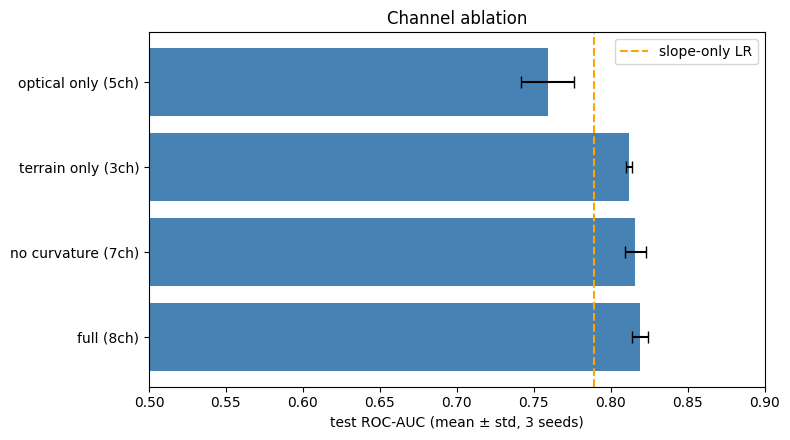

In [ ]:
plt.figure(figsize=(8, 4.5))
plt.barh(S.index, S.roc_mean, xerr=S.roc_std,
         color="steelblue", capsize=4)
plt.axvline(0.789, color="orange", ls="--", label="slope-only LR")
plt.xlim(0.5, 0.9); plt.xlabel("test ROC-AUC (mean ± std, 3 seeds)")
plt.title("Channel ablation")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "09_ablation_seeds.png", dpi=130, bbox_inches="tight")
plt.show()

In [ ]:
class FlatMLP(nn.Module):
    """Identical input, spatial structure destroyed by flattening.
    If the CNN wins, spatial arrangement carries real signal — the
    core claim of a vision-based approach."""
    def __init__(self, in_ch=8, px=64, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(in_ch*px*px, 256), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1))

    def forward(self, x):
        return self.net(x).squeeze(1)


mlp = FlatMLP(len(CHANNELS))
print(f"MLP parameters {sum(p.numel() for p in mlp.parameters()):,} "
      f"(CNN {n_par:,})")
mlp, _ = train_model(mlp, dl_tr, dl_va, "mlp", verbose=False)
pm, ym = predict(mlp, dl_te)
mlp_roc = roc_auc_score(ym, pm)

print(f"\nCNN ROC-AUC {roc:.3f}")
print(f"MLP ROC-AUC {mlp_roc:.3f}")
print(f"gap {roc - mlp_roc:+.3f}")
if roc > mlp_roc:
    print("\nCHECKPOINT PASSED — convolution exploits spatial structure "
          "the MLP cannot access")

MLP parameters 8,405,377 (CNN 294,849)
  early stop at epoch 46
  best val PR-AUC 0.8655 @ epoch 21  (24s, 0.5s/epoch)

CNN ROC-AUC 0.822
MLP ROC-AUC 0.831
gap -0.009


In [ ]:
import torchvision

def make_resnet18(in_ch):
    net = torchvision.models.resnet18(weights="IMAGENET1K_V1")
    old = net.conv1.weight.data                       # (64, 3, 7, 7)
    net.conv1 = nn.Conv2d(in_ch, 64, 7, 2, 3, bias=False)
    with torch.no_grad():
        # initialise new channels from the mean of pretrained RGB filters
        net.conv1.weight.copy_(old.mean(dim=1, keepdim=True).repeat(1, in_ch, 1, 1))
    net.fc = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(512, 1))
    return net

class ResNetWrap(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.net = make_resnet18(in_ch)
    def forward(self, x):
        return self.net(F.interpolate(x, size=128, mode="bilinear",
                                      align_corners=False)).squeeze(1)

rn = ResNetWrap(len(CHANNELS))
rn, _ = train_model(rn, dl_tr, dl_va, "resnet18", lr=3e-4, verbose=False)
prn, yrn = predict(rn, dl_te)
rn_roc = roc_auc_score(yrn, prn)
print(f"\nResNet-18 transfer ROC-AUC {rn_roc:.3f}  (custom CNN {roc:.3f})")

  early stop at epoch 30
  best val PR-AUC 0.7982 @ epoch 5  (70s, 2.3s/epoch)

ResNet-18 transfer ROC-AUC 0.811  (custom CNN 0.822)


In [ ]:
summary = pd.concat([
    baselines[["roc_auc", "pr_auc"]],
    A[["roc_auc", "pr_auc"]],
    pd.DataFrame({"roc_auc": [mlp_roc, rn_roc],
                  "pr_auc": [average_precision_score(ym, pm),
                             average_precision_score(yrn, prn)]},
                 index=["MLP (no spatial structure)", "ResNet-18 transfer"]),
]).sort_values("roc_auc", ascending=False)

print(summary.round(3).to_string())
summary.to_csv(METRIC_DIR / "model_comparison.csv")

plt.figure(figsize=(9, 6))
colors = ["firebrick" if "8ch" in i or "ResNet" in i else "steelblue"
          for i in summary.index[::-1]]
summary.roc_auc[::-1].plot.barh(color=colors)
plt.axvline(0.5, color="k", ls="--", lw=.8)
plt.axvline(SLOPE_AUC, color="orange", ls="--", lw=1.2, label="slope-only")
plt.xlabel("test ROC-AUC"); plt.title("Model comparison — frozen spatial split")
plt.legend(); plt.tight_layout()
plt.savefig(FIG_DIR / "09_model_comparison.png", dpi=130, bbox_inches="tight")
plt.show()